In [1]:
import pandas as pd
import numpy as np

from sklearn.preprocessing import StandardScaler
from sklearn.cluster import KMeans

from sklearn.model_selection import train_test_split

from sklearn.ensemble import RandomForestClassifier

from sklearn.metrics import (
    accuracy_score,
    classification_report,
    confusion_matrix
)

In [2]:
globals().keys()

dict_keys(['__name__', '__doc__', '__package__', '__loader__', '__spec__', '__builtin__', '__builtins__', '_ih', '_oh', '_dh', 'In', 'Out', 'get_ipython', 'exit', 'quit', 'open', '_', '__', '___', '__vsc_ipynb_file__', '_i', '_ii', '_iii', '_i1', 'pd', 'np', 'StandardScaler', 'KMeans', 'train_test_split', 'RandomForestClassifier', 'accuracy_score', 'classification_report', 'confusion_matrix', '_i2'])

In [3]:
import os

for root, dirs, files in os.walk("../data/external"):
    for file in files:
        if file.endswith(".csv"):
            print(os.path.join(root, file))

../data/external\ki_endolist\ki-dataset\Longitudinal_tracking_data_dictionary.csv
../data/external\ki_endolist\ki-dataset\Onboarding_codes_dictionary.csv
../data/external\ki_endolist\ki-dataset\Patient_onboarding_info.csv
../data/external\ki_endolist\ki-dataset\Symptom_MedDRA_map.csv
../data/external\ki_endolist\ki-dataset\User38.csv
../data/external\ki_endolist\ki-dataset\User39.csv
../data/external\ki_endolist\ki-dataset\User41.csv
../data/external\ki_endolist\ki-dataset\User42.csv
../data/external\ki_endolist\ki-dataset\User44.csv
../data/external\ki_endolist\ki-dataset\User47.csv
../data/external\ki_endolist\ki-dataset\User48.csv
../data/external\ki_endolist\ki-dataset\User49.csv
../data/external\ki_endolist\ki-dataset\User50.csv
../data/external\ki_endolist\ki-dataset\User51.csv
../data/external\ki_endolist\ki-dataset\User52.csv
../data/external\ki_endolist\ki-dataset\User53.csv
../data/external\ki_endolist\ki-dataset\User59.csv
../data/external\ki_endolist\ki-dataset\User61.csv
.

In [4]:
import pandas as pd
import os
import glob

files = glob.glob(
    "../data/external/ki_endolist/ki-dataset/User*.csv"
)

dfs = []

for file in files:
    df = pd.read_csv(file)
    dfs.append(df)

all_data = pd.concat(
    dfs,
    ignore_index=True
)

print(all_data.shape)

(5112, 387)


In [5]:
all_data.head()

,User id,Day in study,Week day,Cycle number,Cycle day,First day of period,"Period (0-no, 1-yes)","Migraines (0-no pain, 4-worst pain)","Period pain (0-no pain, 4-worst pain)","Type of stool (0-no stool, 7-bowel blockage)",...,"Groin burning sensation (0-no burning, 10-worst burning)","Muscle tightness (0-no tightness, 10-worst tightness)","Urgency urination (0-no urgency, 10-worst urgency)","Rib pain R (0-no pain, 10-worst pain)","Uterine cramps (0-no cramps, 10-worst cramps)","Pain radiating to the buttock (0-no pain, 10-worst pain)","Vaginal dryness / itching (0-no pain, 10-worst pain)","Stabbing pain in ovaries (0-no pain, 10-worst pain)","Neck muscles cramps L (0-no pain, 10-worst pain)","Burning / numbness / sore feet (0-no pain, 10-worst pain)"
0,38,1,Sat,1.0,1,1.0,1.0,0.0,1.0,5.0,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
1,38,2,Sun,1.0,2,0.0,1.0,0.0,1.0,5.0,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
2,38,3,Mon,1.0,3,0.0,1.0,0.0,0.0,5.0,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
3,38,4,Tue,1.0,4,0.0,0.0,0.0,0.0,4.0,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
4,38,5,Wed,1.0,5,0.0,0.0,0.0,0.0,6.0,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN


In [6]:
all_data.columns[:10]

Index(['User id', 'Day in study', 'Week day', 'Cycle number', 'Cycle day',
       'First day of period', 'Period (0-no, 1-yes)',
       'Migraines (0-no pain, 4-worst pain)',
       'Period pain (0-no pain, 4-worst pain)',
       'Type of stool (0-no stool, 7-bowel blockage)'],
      dtype='str')

In [7]:
state_df = all_data[
    [
        "User id",
        "Day in study",
        "Cycle day",
        "Period (0-no, 1-yes)",
        "Bleeding (0-no bleeding, 4-heaviest bleeding)",
        "General emotional condition (1-bad, 10-amazing)",
        "General physical condition (1-bad, 10-amazing)",
        "Type of stool (0-no stool, 7-bowel blockage)"
    ]
].copy()

state_df = state_df.dropna()

print(state_df.shape)

(1478, 8)


In [8]:
scaler = StandardScaler()

X_cluster = scaler.fit_transform(
    state_df[
        [
            "Cycle day",
            "Period (0-no, 1-yes)",
            "Bleeding (0-no bleeding, 4-heaviest bleeding)",
            "General emotional condition (1-bad, 10-amazing)",
            "General physical condition (1-bad, 10-amazing)",
            "Type of stool (0-no stool, 7-bowel blockage)"
        ]
    ]
)

kmeans = KMeans(
    n_clusters=3,
    random_state=42
)

state_df["State"] = kmeans.fit_predict(X_cluster)

In [9]:
state_df = state_df.sort_values(
    ["User id", "Day in study"]
)

state_df["Tomorrow_State"] = (
    state_df
    .groupby("User id")
    ["State"]
    .shift(-1)
)

state_df = state_df.dropna()

state_df["Tomorrow_State"] = (
    state_df["Tomorrow_State"]
    .astype(int)
)

print(state_df.shape)

(1467, 10)


In [10]:
X = state_df[
    [
        "Cycle day",
        "Period (0-no, 1-yes)",
        "Bleeding (0-no bleeding, 4-heaviest bleeding)",
        "General emotional condition (1-bad, 10-amazing)",
        "General physical condition (1-bad, 10-amazing)",
        "Type of stool (0-no stool, 7-bowel blockage)",
        "State"
    ]
]

y = state_df["Tomorrow_State"]

print(X.shape)
print(y.shape)

(1467, 7)
(1467,)


In [11]:
X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42
)

In [12]:
state_model = RandomForestClassifier(
    n_estimators=300,
    random_state=42
)

state_model.fit(X_train, y_train)

,"n_estimators n_estimators: int, default=100The number of trees in the forest... versionchanged:: 0.22 The default value of ``n_estimators`` changed from 10 to 100 in 0.22.",300
,"random_state random_state: int, RandomState instance or None, default=NoneControls both the randomness of the bootstrapping of the samples usedwhen building trees (if ``bootstrap=True``) and the sampling of thefeatures to consider when looking for the best split at each node(if ``max_features < n_features``).See :term:`Glossary <random_state>` for details.",42
,"criterion criterion: {""gini"", ""entropy"", ""log_loss""}, default=""gini""The function to measure the quality of a split. Supported criteria are""gini"" for the Gini impurity and ""log_loss"" and ""entropy"" both for theShannon information gain, see :ref:`tree_mathematical_formulation`.Note: This parameter is tree-specific.",'gini'
,"max_depth max_depth: int, default=NoneThe maximum depth of the tree. If None, then nodes are expanded untilall leaves are pure or until all leaves contain less thanmin_samples_split samples.",None
,"min_samples_split min_samples_split: int or float, default=2The minimum number of samples required to split an internal node:- If int, then consider `min_samples_split` as the minimum number.- If float, then `min_samples_split` is a fraction and `ceil(min_samples_split * n_samples)` are the minimum number of samples for each split... versionchanged:: 0.18 Added float values for fractions.",2
,"min_samples_leaf min_samples_leaf: int or float, default=1The minimum number of samples required to be at a leaf node.A split point at any depth will only be considered if it leaves atleast ``min_samples_leaf`` training samples in each of the left andright branches. This may have the effect of smoothing the model,especially in regression.- If int, then consider `min_samples_leaf` as the minimum number.- If float, then `min_samples_leaf` is a fraction and `ceil(min_samples_leaf * n_samples)` are the minimum number of samples for each node... versionchanged:: 0.18 Added float values for fractions.",1
,"min_weight_fraction_leaf min_weight_fraction_leaf: float, default=0.0The minimum weighted fraction of the sum total of weights (of allthe input samples) required to be at a leaf node. Samples haveequal weight when sample_weight is not provided.",0.0
,"max_features max_features: {""sqrt"", ""log2"", None}, int or float, default=""sqrt""The number of features to consider when looking for the best split:- If int, then consider `max_features` features at each split.- If float, then `max_features` is a fraction and `max(1, int(max_features * n_features_in_))` features are considered at each split.- If ""sqrt"", then `max_features=sqrt(n_features)`.- If ""log2"", then `max_features=log2(n_features)`.- If None, then `max_features=n_features`... versionchanged:: 1.1 The default of `max_features` changed from `""auto""` to `""sqrt""`.Note: the search for a split does not stop until at least onevalid partition of the node samples is found, even if it requires toeffectively inspect more than ``max_features`` features.",'sqrt'
,"max_leaf_nodes max_leaf_nodes: int, default=NoneGrow trees with ``max_leaf_nodes`` in best-first fashion.Best nodes are defined as relative reduction in impurity.If None then unlimited number of leaf nodes.",None
,"min_impurity_decrease min_impurity_decrease: float, default=0.0A node will be split if this split induces a decrease of the impuritygreater than or equal to this value.The weighted impurity decrease equation is the following:: N_t / N * (impurity - N_t_R / N_t * right_impurity - N_t_L / N_t * left_impurity)where ``N`` is the total number of samples, ``N_t`` is the number ofsamples at the current node, ``N_t_L`` is the number of samples in theleft child, and ``N_t_R`` is the number of samples in the right child.``N``, ``N_t``, ``N_t_R`` and ``N_t_L`` all refer to the weighted sum,if ``sample_weight`` is passed... versionadded:: 0.19",0.0
,"bootstrap bootstr

In [13]:
preds = state_model.predict(X_test)

In [14]:
print("Accuracy:", accuracy_score(y_test, preds))

Accuracy: 0.8095238095238095


In [15]:
print(
    classification_report(
        y_test,
        preds
    )
)

              precision    recall  f1-score   support

           0       0.86      0.87      0.86       175
           1       0.67      0.60      0.63        55
           2       0.78      0.83      0.80        64

    accuracy                           0.81       294
   macro avg       0.77      0.77      0.77       294
weighted avg       0.81      0.81      0.81       294



In [16]:
importance = pd.DataFrame({
    "Feature": X.columns,
    "Importance": state_model.feature_importances_
})

importance.sort_values(
    "Importance",
    ascending=False
)

,Feature,Importance
0,Cycle day,0.258803
6,State,0.190535
4,"General physical condition (1-bad, 10-amazing)",0.130939
3,"General emotional condition (1-bad, 10-amazing)",0.114673
5,"Type of stool (0-no stool, 7-bowel blockage)",0.107557
2,"Bleeding (0-no bleeding, 4-heaviest bleeding)",0.100097
1,"Period (0-no, 1-yes)",0.097396


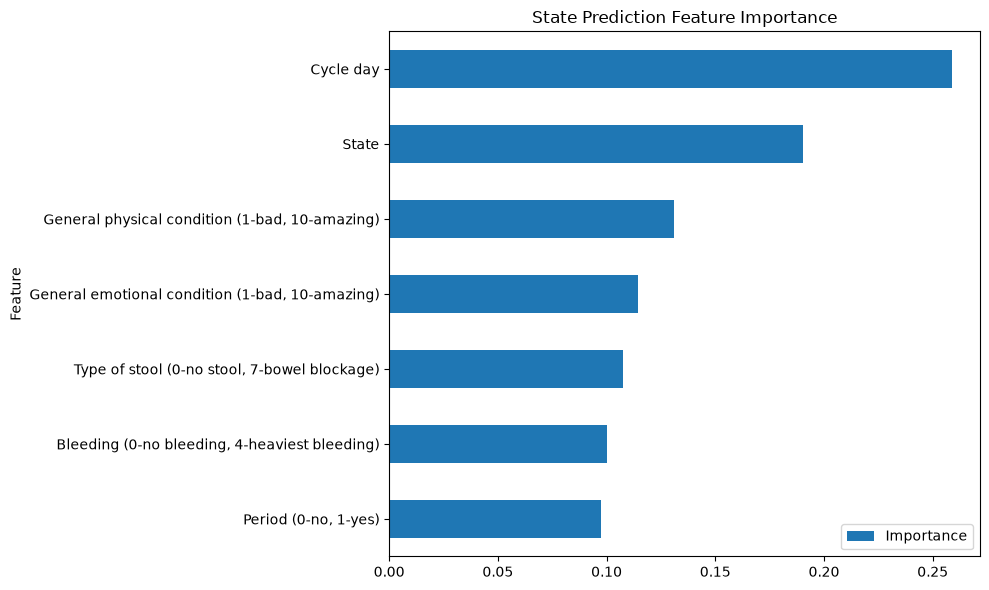

In [17]:
import matplotlib.pyplot as plt

importance.sort_values(
    "Importance",
    ascending=True
).plot(
    x="Feature",
    y="Importance",
    kind="barh",
    figsize=(10,6)
)

plt.title("State Prediction Feature Importance")
plt.tight_layout()

plt.savefig(
    "../docs/figures/state_prediction_feature_importance.png"
)

plt.show()